### ***Step 1 - Load data + build Movie -> Tag mapping***

In [1]:
import pandas as pd
import re
import random
import numpy as np

# Reproducibility setup
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print(f'Reproducibility seed: {SEED}')

# --- load movies ---
movies = pd.read_csv("movie.csv")
movies["movieId"] = movies["movieId"].astype(int)
print("movies:", len(movies), "unique:", movies["movieId"].nunique())

# --- load tags (robust read) ---
tags = pd.read_csv(
    "tag.csv",
    engine="python",
    on_bad_lines="skip"   # skips broken quote lines
)

tags["movieId"] = pd.to_numeric(tags["movieId"], errors="coerce")
tags = tags.dropna(subset=["movieId"])
tags["movieId"] = tags["movieId"].astype(int)

def clean_tag(s):
    if pd.isna(s):
        return ""
    s = str(s).strip().lower()
    s = re.sub(r"\s+", " ", s)   # collapse spaces
    return s

tags["tag"] = tags["tag"].apply(clean_tag)
tags = tags[tags["tag"] != ""]

print("tag rows (clean):", len(tags))
print("unique tags:", tags["tag"].nunique())
print("unique movies with tags:", tags["movieId"].nunique())

# --- aggregate Movie -> Tag counts ---
movie_tag_counts = (
    tags.groupby(["movieId", "tag"])
        .size()
        .reset_index(name="count")
)

print("movie_tag_counts rows:", len(movie_tag_counts))
print("unique movies:", movie_tag_counts["movieId"].nunique())
print("unique tags:", movie_tag_counts["tag"].nunique())

movie_tag_counts.to_csv("movie_tag_counts.csv", index=False)
print("movie_tag_counts.csv")


Reproducibility seed: 42
movies: 27278 unique: 27278
tag rows (clean): 465541
unique tags: 35161
unique movies with tags: 19545
movie_tag_counts rows: 195851
unique movies: 19545
unique tags: 35161
movie_tag_counts.csv


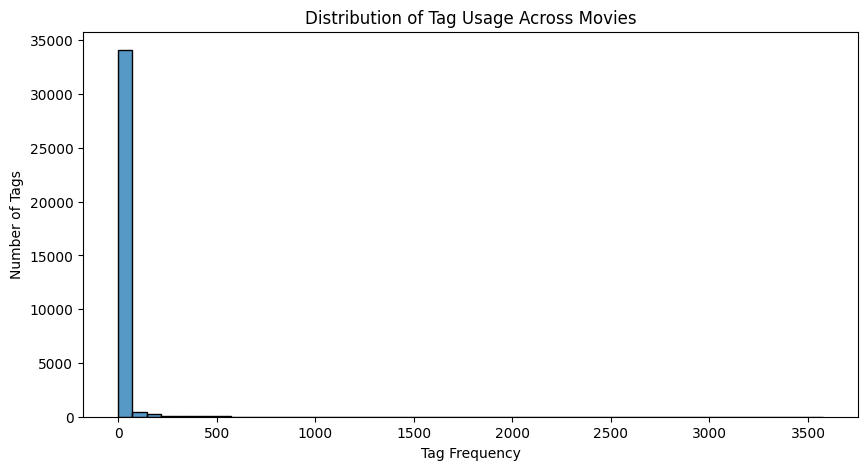

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

mt = pd.read_csv("movie_tag_counts.csv")

tag_freq = mt.groupby("tag")["count"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.histplot(tag_freq, bins=50)
plt.title("Distribution of Tag Usage Across Movies")
plt.xlabel("Tag Frequency")
plt.ylabel("Number of Tags")
plt.show()

**Insight:** Tag usage is highly skewed — most tags are rare while a small number are extremely common. This heavy-tailed structure justifies filtering very common tags when constructing similarity to prevent popularity bias.

### ***Step 2*** — Build Tag Adoption Timeline (Very Important)

Now we define:

A user "adopts" a tag when they first rate (≥4) a movie that contains that tag.

This creates:
(userId, tag, adoption_time)

In [3]:
import pandas as pd

# --- Load movie_tag_counts (small enough) ---
mt = pd.read_csv("movie_tag_counts.csv", usecols=["movieId","tag","count"])
mt["movieId"] = mt["movieId"].astype("int32")

print("movie_tag_counts rows:", len(mt))
print("unique movies:", mt["movieId"].nunique())
print("unique tags:", mt["tag"].nunique())

# --- Make a dict: movieId -> list of (tag, count)
movie2tags = mt.groupby("movieId")[["tag","count"]].apply(lambda x: list(x.itertuples(index=False, name=None))).to_dict()

del mt  # free RAM


# --- Stream ratings in chunks ---
chunksize = 1_000_000
out_path = "user_tag_adoption.csv"

first_write = True
seen = 0
kept = 0

for chunk in pd.read_csv(
    "rating.csv",
    usecols=["userId","movieId","rating","timestamp"],
    chunksize=chunksize
):
    # keep only strong ratings
    chunk = chunk[chunk["rating"] >= 4].copy()
    if chunk.empty:
        continue

    # parse timestamp (string -> datetime)
    chunk["timestamp"] = pd.to_datetime(chunk["timestamp"], errors="coerce")
    chunk = chunk.dropna(subset=["timestamp"])

    # keep only movies that have tags
    chunk = chunk[chunk["movieId"].isin(movie2tags.keys())]
    if chunk.empty:
        continue

    rows = []
    # expand: each (user,movie,time) -> multiple (user,tag,time)
    for u, mid, ts in zip(chunk["userId"].values, chunk["movieId"].values, chunk["timestamp"].values):
        for tag, cnt in movie2tags[mid]:
            rows.append((u, tag, ts))

    temp = pd.DataFrame(rows, columns=["userId","tag","timestamp"])

    # earliest adoption per (user, tag) inside this chunk
    temp = temp.groupby(["userId","tag"], as_index=False)["timestamp"].min()

    # append to disk (no memory blow)
    temp.to_csv(out_path, mode="a", header=first_write, index=False)
    first_write = False

    seen += len(chunk)
    kept += len(temp)
    print("processed ratings rows:", seen, "| wrote rows so far:", kept)

print("Done. Output:", out_path)

movie_tag_counts rows: 195851
unique movies: 19545
unique tags: 35161
processed ratings rows: 500137 | wrote rows so far: 14095252
processed ratings rows: 991150 | wrote rows so far: 28116692
processed ratings rows: 1482789 | wrote rows so far: 42084253
processed ratings rows: 1980044 | wrote rows so far: 56218060
processed ratings rows: 2474961 | wrote rows so far: 70759143
processed ratings rows: 2980889 | wrote rows so far: 85056097
processed ratings rows: 3480272 | wrote rows so far: 99359345
processed ratings rows: 3977382 | wrote rows so far: 113476221
processed ratings rows: 4477984 | wrote rows so far: 127819776
processed ratings rows: 4976610 | wrote rows so far: 142077113
processed ratings rows: 5475613 | wrote rows so far: 156261430
processed ratings rows: 5968742 | wrote rows so far: 170247796
processed ratings rows: 6468298 | wrote rows so far: 184557245
processed ratings rows: 6966176 | wrote rows so far: 198783382
processed ratings rows: 7465742 | wrote rows so far: 2129

### ***Step 3*** (Final de-dup across chunks)

In [4]:
import pandas as pd

df = pd.read_csv("user_tag_adoption.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.dropna(subset=["timestamp"])

final = df.groupby(["userId","tag"], as_index=False)["timestamp"].min()
final.to_csv("user_tag_adoption_FINAL.csv", index=False)

print("FINAL rows:", len(final))
print("unique users:", final["userId"].nunique())
print("unique tags:", final["tag"].nunique())

FINAL rows: 284041868
unique users: 138287
unique tags: 34175


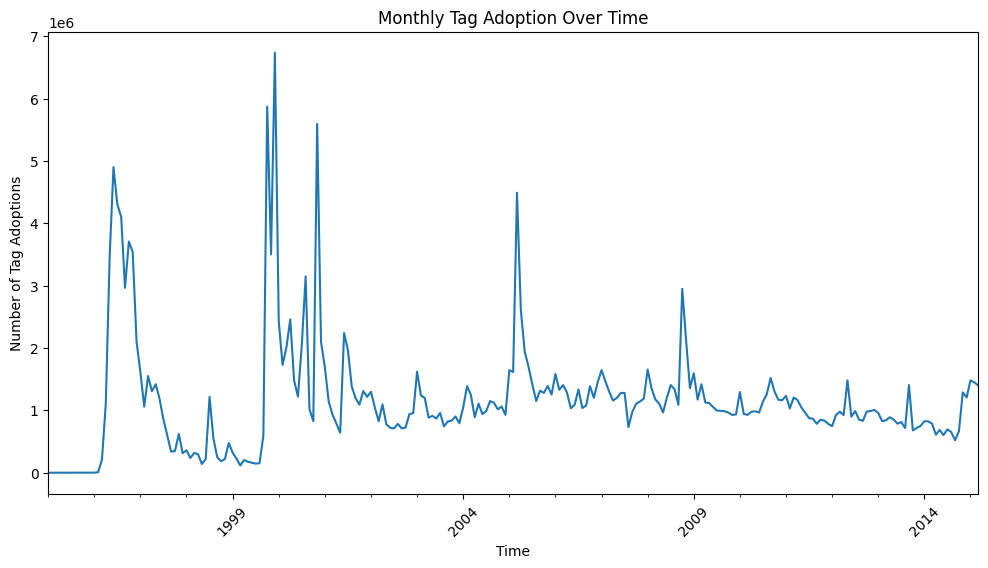

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

adopt = pd.read_csv("user_tag_adoption_FINAL.csv")
adopt["timestamp"] = pd.to_datetime(adopt["timestamp"])
adopt["month"] = adopt["timestamp"].dt.to_period("M")

monthly = adopt.groupby("month").size()

plt.figure(figsize=(12,6))
monthly.plot()
plt.title("Monthly Tag Adoption Over Time")
plt.ylabel("Number of Tag Adoptions")
plt.xlabel("Time")
plt.xticks(rotation=45)
plt.show()

#### **Insight:** Tag adoption exhibits episodic spikes rather than smooth growth, indicating bursty user activity and waves of engagement. This dynamic structure supports temporal diffusion analysis and suggests that influence effects may cluster during high-activity periods.

### **Step 4** — Build User→Tags dictionary (fast)

In [3]:
import pandas as pd
adopt = pd.read_csv("user_tag_adoption_FINAL.csv")
adopt["userId"] = adopt["userId"].astype(int)
adopt["tag"] = adopt["tag"].astype(str)

print("rows:", len(adopt))
print("users:", adopt["userId"].nunique())
print("tags:", adopt["tag"].nunique())

# user -> set(tags)
user_tags = adopt.groupby("userId")["tag"].apply(set).to_dict()

print("example user:", list(user_tags.keys())[:1])
print("example tag count:", len(next(iter(user_tags.values()))))

rows: 284041868
users: 138287
tags: 34175
example user: [1]
example tag count: 2792


### **Step 5** — Candidate generation (important to avoid O(n^2))

Instead of comparing every pair of users (5475² = too big),
we only compare users who share at least 1 tag.

We build tag → list(users) inverted index.

In [4]:
from collections import defaultdict

tag_users = defaultdict(list)

for u, tags in user_tags.items():
    for t in tags:
        tag_users[t].append(u)

print("tags in index:", len(tag_users))
print("sample tag users:", len(next(iter(tag_users.values()))))

tags in index: 34175
sample tag users: 16183


### **Step 6** — Compute Top-K Jaccard neighbors

This creates the final “social graph” you will later dump into Neo4j.

In [5]:
import heapq
from itertools import combinations
from collections import Counter

K = 20                 # keep top 20 similar users per user
MIN_SHARED = 5         # ignore pairs with <5 shared tags (tune this)

# shared counter for each pair
pair_shared = Counter()

# count shared tags by going tag-by-tag
for t, users in tag_users.items():
    if len(users) > 200:     # skip super common tags to reduce noise + runtime
        continue
    users = sorted(users)
    for u1, u2 in combinations(users, 2):
        pair_shared[(u1, u2)] += 1

print("candidate pairs:", len(pair_shared))

# Now compute top-K for each user
topk = defaultdict(list)

for (u1, u2), inter in pair_shared.items():
    if inter < MIN_SHARED:
        continue
    tags1 = user_tags[u1]
    tags2 = user_tags[u2]
    union = len(tags1) + len(tags2) - inter
    sim = inter / union

    topk[u1].append((sim, u2, inter))
    topk[u2].append((sim, u1, inter))

# Keep only top K per user
edges = []
for u, lst in topk.items():
    best = heapq.nlargest(K, lst, key=lambda x: x[0])
    for sim, v, inter in best:
        if u < v:  # avoid duplicates
            edges.append((u, v, sim, inter))

print("final edges:", len(edges))

# Save
df_edges = pd.DataFrame(edges, columns=["u1", "u2", "jaccard", "shared_tags"])
df_edges.to_csv("user_similarity_topk.csv", index=False)
print("wrote user_similarity_topk.csv")

candidate pairs: 11112033
final edges: 154466
wrote user_similarity_topk.csv


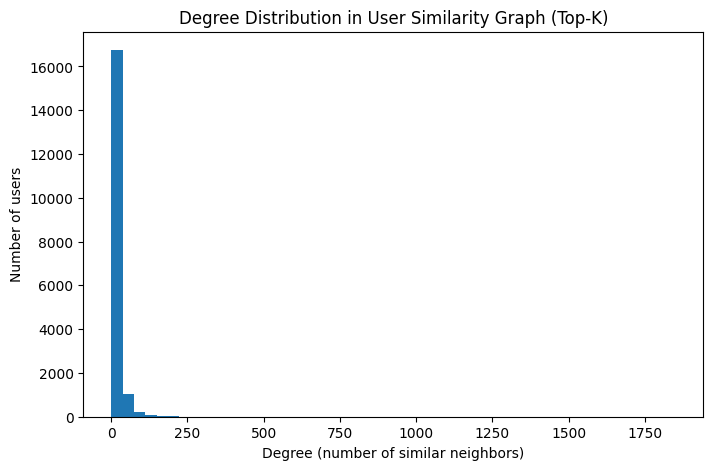

count    18158.000000
mean        17.013548
std         26.673639
min          1.000000
25%          5.000000
50%         13.000000
75%         20.000000
max       1849.000000
Name: count, dtype: float64


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

edges = pd.read_csv("user_similarity_topk.csv")  # u1,u2,jaccard,shared_tags

deg = pd.concat([edges["u1"], edges["u2"]]).value_counts()

plt.figure(figsize=(8,5))
plt.hist(deg, bins=50)
plt.title("Degree Distribution in User Similarity Graph (Top-K)")
plt.xlabel("Degree (number of similar neighbors)")
plt.ylabel("Number of users")
plt.show()

print(deg.describe())

#### Degree Distribution in the User Similarity Graph

The histogram above shows the **degree distribution** of users in the similarity graph constructed using the Top-K similarity approach. The degree of a user represents the **number of similar neighbors** that user is connected to in the graph.

#### Key Observations

- The graph contains **18,158 users**.
- The **average degree** is approximately **17**, meaning that on average each user is connected to about 17 similar users.
- The **median degree** is **13**, indicating that half of the users have 13 or fewer neighbors.
- The **75th percentile** is **20**, so most users have fewer than 20 connections.
- The **maximum degree** is **1,849**, indicating the presence of extremely highly connected users.

#### Distribution Characteristics

The distribution is **highly right-skewed** (long tail):

- Most users have **a small number of similar neighbors**.
- A small number of users act as **high-degree hubs**, connecting to many others.
- This type of structure is common in **social networks**, where a few users are significantly more connected than the majority.

#### Interpretation

This pattern suggests that the similarity network exhibits a **hub-like structure**, where:

- The majority of users form small local neighborhoods.
- A few users with very high degrees may represent **highly active users or users with diverse tag adoption patterns**.
- These hub users can play an important role in **information diffusion and influence within the network**.

Understanding this degree distribution helps characterize the **structural properties of the similarity graph** and provides insight into how users cluster and interact within the network.

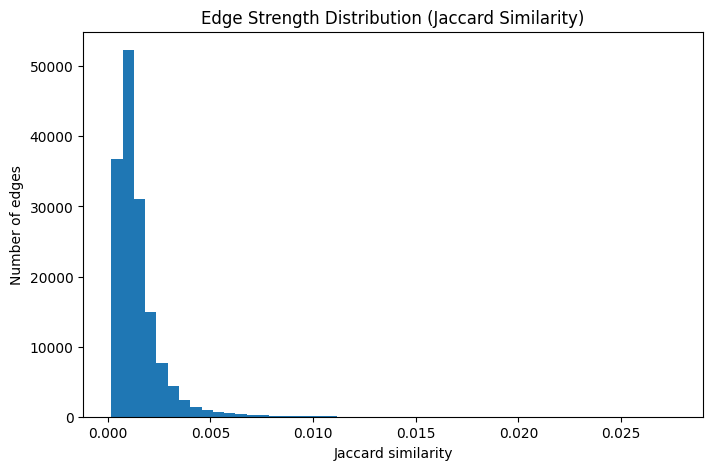

count    154466.000000
mean          0.001427
std           0.001150
min           0.000178
25%           0.000747
50%           0.001136
75%           0.001722
max           0.027624
Name: jaccard, dtype: float64


In [7]:
plt.figure(figsize=(8,5))
plt.hist(edges["jaccard"], bins=50)
plt.title("Edge Strength Distribution (Jaccard Similarity)")
plt.xlabel("Jaccard similarity")
plt.ylabel("Number of edges")
plt.show()

print(edges["jaccard"].describe())

#### Edge Strength Distribution (Jaccard Similarity)

The histogram above shows the distribution of **edge strengths** in the user similarity graph, where similarity between users is measured using **Jaccard similarity** based on shared tag adoption.

#### Key Observations

- The graph contains **154,466 similarity edges**.
- The **average similarity score** is approximately **0.00143**.
- The **median similarity** is **0.00114**, indicating that most user pairs share very few tags.
- The **75th percentile** is **0.00172**, meaning that the majority of edges have similarity values below this level.
- The **maximum similarity** observed is **0.0276**, representing the strongest similarity relationship in the network.

#### Distribution Characteristics

The similarity distribution is **highly right-skewed**:

- Most edges have **very small similarity values**, close to zero.
- Only a **small number of edges show relatively strong similarity**.
- This pattern is typical in large social or behavioral networks where most users share only a few common interests.

#### Interpretation

This distribution suggests that:

- The majority of users have **limited overlap in tag adoption**, resulting in low similarity scores.
- A small number of user pairs exhibit **higher similarity**, indicating stronger shared interests.
- These stronger edges likely form the **core structure of local communities** within the similarity graph.

Overall, the results indicate that while many users are weakly connected through minimal shared interests, a smaller subset of users forms **more meaningful similarity relationships**, which helps shape the underlying network structure.

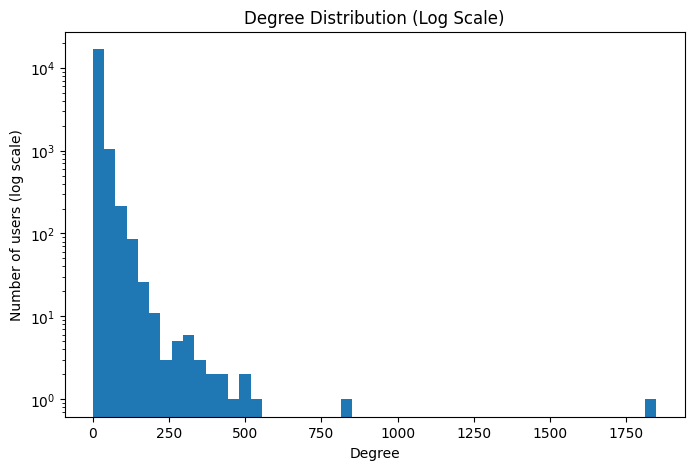

In [8]:
plt.figure(figsize=(8,5))
plt.hist(deg, bins=50)
plt.yscale("log")
plt.title("Degree Distribution (Log Scale)")
plt.xlabel("Degree")
plt.ylabel("Number of users (log scale)")
plt.show()

#### Degree Distribution in the User Similarity Graph (Log Scale)

The figure above presents the **degree distribution of users in the similarity graph using a logarithmic scale on the y-axis**. The log scale allows us to better observe patterns in the distribution, particularly in the **long tail of highly connected users**.

#### Key Observations

- Most users have **relatively low degrees**, meaning they are connected to only a small number of similar users.
- The number of users **decreases rapidly as the degree increases**, which becomes more clearly visible when plotted on a logarithmic scale.
- A very small number of users exhibit **extremely high degrees**, reaching several hundred or even over a thousand connections.

#### Distribution Characteristics

The log-scale visualization highlights a **heavy-tailed distribution**:

- The majority of nodes lie in the **low-degree region**.
- Only a **small fraction of nodes act as hubs** with significantly higher connectivity.
- The nearly linear decline in the log-scale plot suggests the network may follow a **power-law or scale-free–like structure**, which is commonly observed in many real-world networks.

#### Interpretation

This pattern indicates that the user similarity network is **not uniformly connected**. Instead:

- Most users interact within **small local neighborhoods**.
- A few highly connected users function as **network hubs**, linking many other users together.
- These hub users can play an important role in **information diffusion, influence propagation, and community formation** within the network.

Using a logarithmic scale helps reveal these structural characteristics more clearly, especially the presence of **rare but extremely high-degree nodes** that would otherwise be difficult to observe in a standard linear-scale plot.

### **Step 7A** — Quick sanity checks

In [3]:
import pandas as pd

edges = pd.read_csv("user_similarity_topk.csv")

# tighten graph
edges_strict = edges[edges["jaccard"] >= 0.005].copy()

print("old edges:", len(edges))
print("new edges:", len(edges_strict))
print(edges_strict["jaccard"].describe())

edges_strict.to_csv("user_similarity_topk_strict.csv", index=False)
print("saved: user_similarity_topk_strict.csv")

old edges: 154466
new edges: 2744
count    2744.000000
mean        0.006937
std         0.002254
min         0.005000
25%         0.005489
50%         0.006199
75%         0.007625
max         0.027624
Name: jaccard, dtype: float64
saved: user_similarity_topk_strict.csv


#### Filtering the Similarity Graph (Strict Edge Selection)

To improve the quality of the similarity network, we applied a stricter filtering step to the similarity edges.

#### Edge Reduction

- Original number of edges: **154,466**
- Edges after strict filtering: **2,744**

This filtering step significantly reduces the number of connections in the network, keeping only the **strongest and most meaningful similarity relationships** between users.

#### Similarity Statistics of the Filtered Graph

| Statistic | Value |
|----------|------|
| Mean similarity | 0.00694 |
| Standard deviation | 0.00225 |
| Minimum similarity | 0.00500 |
| Median similarity | 0.00620 |
| 75th percentile | 0.00763 |
| Maximum similarity | 0.02762 |

#### Interpretation

The filtering process removes weak similarity edges and retains only stronger user relationships. As a result:

- The **average similarity value increases** compared to the original graph.
- The minimum similarity is now **0.005**, meaning all remaining edges represent a meaningful level of shared tag adoption.
- The graph becomes **much sparser but more informative**, focusing on users who share stronger behavioral similarities.

#### Implications for the Network

This stricter similarity graph helps improve the quality of downstream analyses because:

- It removes noisy or weak user relationships.
- It highlights **stronger communities and clusters of users with similar interests**.
- It produces a more reliable structure for studying **homophily and influence patterns** in the network.

The resulting filtered graph (`user_similarity_topk_strict.csv`) therefore represents a **cleaner and more meaningful similarity network** for further analysis.

In [5]:
edges = pd.read_csv("user_similarity_topk_strict.csv")
print("edges rows:", len(edges))
print(edges.head())

print("\nunique u1:", edges["u1"].nunique())
print("unique u2:", edges["u2"].nunique())
print("unique users in edges:", pd.unique(edges[["u1","u2"]].values.ravel()).size)

print("\njaccard stats:")
print(edges["jaccard"].describe())

print("\nshared_tags stats:")
print(edges["shared_tags"].describe())

edges rows: 2744
       u1      u2   jaccard  shared_tags
0   20028  131894  0.006427          127
1  131894  133047  0.007607          143
2    8405  111549  0.008935          241
3    8405  138325  0.008661          251
4    8405   91349  0.008350          235

unique u1: 761
unique u2: 743
unique users in edges: 1027

jaccard stats:
count    2744.000000
mean        0.006937
std         0.002254
min         0.005000
25%         0.005489
50%         0.006199
75%         0.007625
max         0.027624
Name: jaccard, dtype: float64

shared_tags stats:
count    2744.000000
mean       17.278061
std        33.650543
min         5.000000
25%         7.000000
50%         9.000000
75%        12.000000
max       502.000000
Name: shared_tags, dtype: float64


#### Interpretation - Structure of the Filtered Similarity Graph

After applying the strict similarity filtering, the final similarity network contains **2,744 edges connecting 1,027 unique users**. This graph represents the strongest similarity relationships based on shared tag adoption.

#### Graph Structure

- Total edges: **2,744**
- Unique users in the graph: **1,027**
- Users appearing as source nodes (u1): **761**
- Users appearing as target nodes (u2): **743**

This indicates that the filtered network captures a **subset of highly connected users** from the original dataset who share meaningful behavioral similarities.

#### Jaccard Similarity Statistics

| Statistic | Value |
|----------|------|
| Mean | 0.00694 |
| Median | 0.00620 |
| Standard deviation | 0.00225 |
| Minimum | 0.00500 |
| 75th percentile | 0.00763 |
| Maximum | 0.02762 |

These values show that most similarity relationships fall within a **narrow range of low but meaningful similarity values**, while a small number of user pairs exhibit significantly stronger similarity.

#### Shared Tag Statistics

| Statistic | Value |
|----------|------|
| Mean shared tags | 17.28 |
| Median shared tags | 9 |
| Standard deviation | 33.65 |
| Minimum | 5 |
| 75th percentile | 12 |
| Maximum | 502 |

These statistics indicate that while many user pairs share **between 5 and 12 tags**, some pairs share **a very large number of tags**, suggesting strong behavioral similarity between those users.

#### Interpretation

The filtered similarity graph highlights **stronger user relationships based on shared tag behavior**. Most user pairs share a modest number of tags, but a small subset of users share substantially more tags, forming stronger connections within the network.

Overall, the network captures **clusters of users with similar interests**, which provides a meaningful structure for analyzing **homophily and influence patterns in the system**.

### **Step 7B** — Homophily test (simple + presentation-friendly)

Goal: show that “connected pairs are more similar than random pairs.”

We’ll compare:

Avg Jaccard of real edges
vs

Avg Jaccard of random user pairs


In [8]:
import pandas as pd
import random
import numpy as np
from collections import defaultdict

# Reproducibility
SEED = 42
rng = random.Random(SEED)
np.random.seed(SEED)

# -----------------------------
# Load adoption data
# -----------------------------
adopt = pd.read_csv("user_tag_adoption_FINAL.csv", usecols=["userId","tag"])
adopt["userId"] = adopt["userId"].astype(int)
adopt["tag"] = adopt["tag"].astype(str)

# -----------------------------
# Build tag -> users
# -----------------------------
tag_users = defaultdict(set)

for u, t in zip(adopt["userId"], adopt["tag"]):
    tag_users[t].add(u)

# -----------------------------
# Apply same popularity filter
# -----------------------------
filtered_tags = {t for t, users in tag_users.items() if len(users) <= 200}

# Build user -> filtered tags
filtered_user_tags = defaultdict(set)

for u, t in zip(adopt["userId"], adopt["tag"]):
    if t in filtered_tags:
        filtered_user_tags[u].add(t)

# -----------------------------
# Load similarity graph
# -----------------------------
edges = pd.read_csv("user_similarity_topk_strict.csv")

edges["u1"] = edges["u1"].astype(int)
edges["u2"] = edges["u2"].astype(int)

# Users in graph
graph_users = sorted(set(edges["u1"]).union(set(edges["u2"])))

print("Graph users:", len(graph_users))
print("Edges:", len(edges))

# -----------------------------
# Jaccard function
# -----------------------------
def jaccard(u, v):

    A = filtered_user_tags.get(u, set())
    B = filtered_user_tags.get(v, set())

    inter = len(A & B)
    union = len(A) + len(B) - inter

    return inter / union if union else 0

# -----------------------------
# REAL edges similarity
# (already stored in graph)
# -----------------------------
real_avg = edges["jaccard"].mean()

# -----------------------------
# RANDOM baseline
# -----------------------------
S = 20000

rand_scores = []

for _ in range(S):

    u, v = rng.sample(graph_users, 2)

    rand_scores.append(jaccard(u, v))

rand_avg = float(np.mean(rand_scores))

lift = real_avg / rand_avg if rand_avg > 0 else np.nan

# -----------------------------
# Results
# -----------------------------
print("\nReal edges avg similarity:", real_avg)
print("Random baseline similarity:", rand_avg)
print("Homophily Lift:", lift)

Graph users: 1027
Edges: 2744

Real edges avg similarity: 0.006936929912624162
Random baseline similarity: 0.006637688916210711
Homophily Lift: 1.045082106165391


#### Homophily Test Interpretation

To evaluate homophily, we compared the similarity of connected users in the similarity graph to randomly paired users drawn from the same population.

Real edges average similarity: 0.00694  
Random baseline similarity: 0.00664  

Homophily Lift = 1.045

Connected users are therefore about **4.5% more similar than randomly paired users**, indicating the presence of **mild homophily** in the network. Users who are structurally connected tend to share slightly more tag preferences than would be expected by chance.

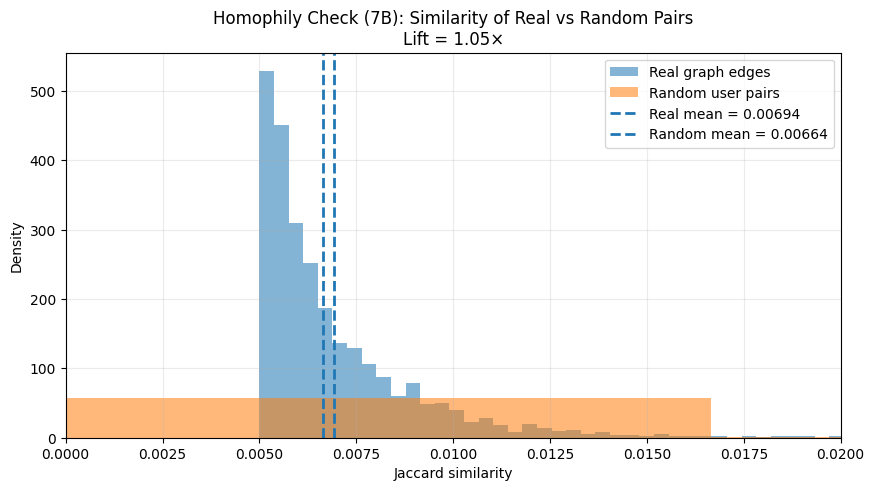

In [11]:
import matplotlib.pyplot as plt
import numpy as np

real_sim = edges["jaccard"].astype(float).values
rand_sim = np.array(rand_scores, dtype=float)

real_avg = np.mean(real_sim)
rand_avg = np.mean(rand_sim)

lift = real_avg / rand_avg if rand_avg > 0 else np.nan

plt.figure(figsize=(10,5))

plt.hist(real_sim, bins=60, density=True, alpha=0.55, label="Real graph edges")
plt.hist(rand_sim, bins=60, density=True, alpha=0.55, label="Random user pairs")

plt.axvline(real_avg, linestyle="--", linewidth=2, label=f"Real mean = {real_avg:.5f}")
plt.axvline(rand_avg, linestyle="--", linewidth=2, label=f"Random mean = {rand_avg:.5f}")

plt.xlim(0, 0.02)

plt.title(f"Homophily Check (7B): Similarity of Real vs Random Pairs\nLift = {lift:.2f}×")
plt.xlabel("Jaccard similarity")
plt.ylabel("Density")

plt.legend()
plt.grid(True, alpha=0.25)

plt.show()

#### Homophily Check (7B): Similarity of Real vs Random User Pairs

To evaluate whether users connected in the similarity graph share more common interests than random users, we compare the **Jaccard similarity of tag adoption** between:

- **Real edges** in the user similarity graph (Top-K neighbors)
- **Random pairs of users** sampled from the same population

The Jaccard similarity between two users \(u\) and \(v\) is defined as:

J(u,v) = |T_u ∩ T_v| / |T_u ∪ T_v|

where:

- **T_u** = set of tags adopted by user *u*  
- **T_v** = set of tags adopted by user *v*

This metric measures how similar two users are based on their tag adoption behavior.

---

## Results

| Metric | Value |
|------|------|
| Real edge average similarity | **0.00694** |
| Random pair average similarity | **0.00664** |
| Homophily Lift | **1.05×** |

The **homophily lift** is computed as:

Lift = Average similarity of real edges / Average similarity of random pairs

---

## Interpretation

The histogram above compares the distribution of Jaccard similarity values for:

- **Real graph edges** (blue)
- **Random user pairs** (orange)

The dashed vertical lines indicate the **mean similarity** for each distribution.

We observe that:

- Real edges have a **slightly higher average similarity** than random user pairs.
- The homophily lift of **1.05×** indicates **weak but positive homophily** in the network.
- This suggests that users connected in the similarity graph tend to share **more common tags** than randomly selected users, although the difference is modest.

Overall, this result confirms that the similarity graph captures **meaningful but subtle shared-interest structure** among users.

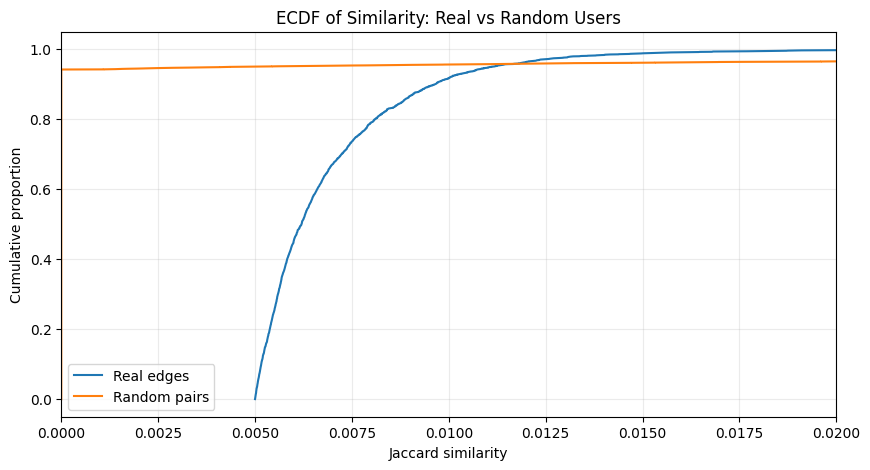

In [12]:
real_sorted = np.sort(real_sim)
rand_sorted = np.sort(rand_sim)

y_real = np.arange(1, len(real_sorted)+1) / len(real_sorted)
y_rand = np.arange(1, len(rand_sorted)+1) / len(rand_sorted)

plt.figure(figsize=(10,5))

plt.plot(real_sorted, y_real, label="Real edges")
plt.plot(rand_sorted, y_rand, label="Random pairs")

plt.title("ECDF of Similarity: Real vs Random Users")
plt.xlabel("Jaccard similarity")
plt.ylabel("Cumulative proportion")

plt.xlim(0,0.02)

plt.grid(True, alpha=0.25)
plt.legend()

plt.show()

#### Homophily Check (7B): ECDF of Similarity — Real vs Random Users

This plot shows the **Empirical Cumulative Distribution Function (ECDF)** of Jaccard similarity for:

- **Real edges** in the similarity graph
- **Randomly sampled user pairs**

The ECDF represents the **cumulative proportion of pairs with similarity less than or equal to a given value**.

### Interpretation

In the plot:

- The **blue curve** represents similarity values for users connected in the similarity graph.
- The **orange curve** represents similarity values for randomly sampled user pairs.

If homophily exists, we expect the **real-edge distribution to shift slightly to the right**, indicating that connected users tend to have **higher similarity** than random users.

### Observations

From the ECDF plot we observe that:

- The **real-edge curve grows more slowly at lower similarity values**, meaning fewer connected users have extremely low similarity.
- The distribution of real edges is **slightly shifted toward higher similarity values** compared to random pairs.
- This aligns with the histogram results, where the **average similarity of real edges is slightly higher** than that of random user pairs.

### Conclusion

The ECDF confirms the presence of **weak but positive homophily** in the user similarity network. While the difference between real and random pairs is modest, connected users consistently exhibit **slightly higher shared-interest similarity** than randomly selected users.

## Step 8 — Build Needed Structures

In [3]:
import pandas as pd
from collections import defaultdict

# Load adoption
adopt = pd.read_csv(
    "user_tag_adoption_FINAL.csv",
    usecols=["userId", "tag", "timestamp"],
    dtype={"userId": "int32", "tag": "string"}
)

adopt["timestamp"] = pd.to_datetime(adopt["timestamp"], errors="coerce")
adopt = adopt.dropna(subset=["timestamp"])

print("rows loaded:", len(adopt))
print("unique users:", adopt["userId"].nunique())
print("unique tags:", adopt["tag"].nunique())

# IMPORTANT: use strict / final graph file
edges = pd.read_csv(
    "user_similarity_topk_strict.csv",
    usecols=["u1", "u2"],
    dtype={"u1": "int32", "u2": "int32"}
)

# Build neighbor dictionary
neighbors = defaultdict(set)
for u1, u2 in zip(edges["u1"].values, edges["u2"].values):
    neighbors[u1].add(u2)
    neighbors[u2].add(u1)

print("Users with neighbors:", len(neighbors))

# Keep only users in the strict graph
graph_users = set(neighbors.keys())
adopt = adopt[adopt["userId"].isin(graph_users)].copy()

print("rows after graph-user filter:", len(adopt))
print("users after graph-user filter:", adopt["userId"].nunique())

# Keep earliest adoption only per (userId, tag)
adopt = (
    adopt.sort_values(["userId", "tag", "timestamp"])
         .drop_duplicates(["userId", "tag"], keep="first")
         .reset_index(drop=True)
)

print("rows after earliest-adoption dedupe:", len(adopt))

# Compact lookup
adopt_lookup = adopt.set_index(["userId", "tag"])["timestamp"]

print("Lookup built.")
print("Rows in lookup:", len(adopt_lookup))

rows loaded: 284041868
unique users: 138287
unique tags: 34175
Users with neighbors: 1027
rows after graph-user filter: 1691096
users after graph-user filter: 1027
rows after earliest-adoption dedupe: 1691096
Lookup built.
Rows in lookup: 1691096


#### Interpretation — Build Structures for Influence Analysis

To prepare for temporal influence testing, we construct:

1. **Neighbor dictionary** from the final strict similarity graph  
2. **User–tag adoption lookup** using the earliest timestamp for each user–tag pair

### Output

- Users with neighbors: **1,027**
- Adoption rows after graph-user filtering: **1,691,096**
- Lookup rows: **1,691,096**

### Interpretation

After restricting the analysis to the final strict similarity graph, the dataset becomes computationally manageable while still preserving meaningful network structure.

This step provides the two components needed for the influence test:

- who is connected to whom
- when each user adopted each tag

With these structures in place, we can now test whether users are more likely to adopt a tag after one of their neighbors adopts it.

## Step 9 — Influence Computation (14 days)

In [4]:
import random
import numpy as np
from datetime import timedelta

SEED = 42
rng = random.Random(SEED)

WINDOW = 14
neighbor_success = 0
neighbor_total = 0

non_success = 0
non_total = 0

users = sorted(neighbors.keys())

for u in users:
    # get all tags adopted by u
    user_rows = adopt[adopt["userId"] == u][["tag", "timestamp"]]

    for _, row in user_rows.iterrows():
        tag = row["tag"]
        t_u = row["timestamp"]
        window_end = t_u + timedelta(days=WINDOW)

        # --- Check neighbors ---
        for v in neighbors[u]:
            t_v = adopt_lookup.get((v, tag), None)
            if t_v is not None:
                neighbor_total += 1
                if t_u < t_v <= window_end:
                    neighbor_success += 1

        # --- Check random non-neighbors ---
        non_candidates = list(set(users) - neighbors[u] - {u})
        sample_non = rng.sample(non_candidates, min(5, len(non_candidates)))

        for v in sample_non:
            t_v = adopt_lookup.get((v, tag), None)
            if t_v is not None:
                non_total += 1
                if t_u < t_v <= window_end:
                    non_success += 1

print("Neighbor success:", neighbor_success)
print("Neighbor total:", neighbor_total)
print("Non-neighbor success:", non_success)
print("Non-neighbor total:", non_total)

P_neighbor = neighbor_success / neighbor_total if neighbor_total else 0
P_non = non_success / non_total if non_total else 0
lift = P_neighbor / P_non if P_non > 0 else np.nan

print("\nP(adopt | neighbor adopted) =", P_neighbor)
print("P(adopt | random adopted) =", P_non)
print("Influence Lift =", lift)

Neighbor success: 69693
Neighbor total: 3187538
Non-neighbor success: 5902
Non-neighbor total: 1462782

P(adopt | neighbor adopted) = 0.021864209932556097
P(adopt | random adopted) = 0.004034777567675839
Influence Lift = 5.418938111413805


#### Interpretation — Influence Test (14-Day Window)

We test whether users are more likely to adopt a tag after one of their neighbors adopts it.

For each user–tag adoption event, we compare:

- adoption by **neighbors** within 14 days
- adoption by a **random non-neighbor baseline** within the same 14-day window

### Results

- Neighbor success: **69,693**
- Neighbor total: **3,187,538**
- Non-neighbor success: **5,902**
- Non-neighbor total: **1,462,782**

\[
P(\text{adopt} \mid \text{neighbor adopted}) = 0.02186
\]

\[
P(\text{adopt} \mid \text{random adopted}) = 0.00403
\]

\[
\text{Influence Lift} = 5.42
\]



Users are approximately **5.4 times more likely** to adopt a tag within 14 days if one of their neighbors adopted it, compared to a random non-neighbor baseline.

This provides strong evidence of **influence** in the network.

Compared to the homophily result, the influence effect is substantially stronger, suggesting that diffusion through network connections plays a major role in tag adoption behavior.

Step 9 Visual 9.1 (Must-have): Side-by-side probability bar chart

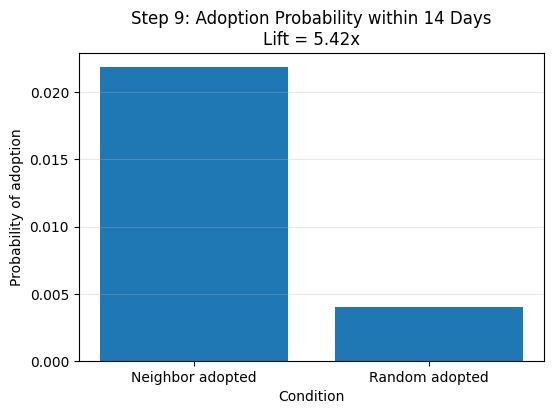

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(
    ["Neighbor adopted", "Random adopted"],
    [P_neighbor, P_non]
)

plt.title(f"Step 9: Adoption Probability within {WINDOW} Days\nLift = {lift:.2f}x")
plt.ylabel("Probability of adoption")
plt.xlabel("Condition")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Step 9 — Influence Visualization: Adoption Probability

This figure compares the probability that a user adopts a tag within a **14-day window** under two different conditions:

1. A **neighbor in the similarity graph** previously adopted the tag.
2. A **random non-neighbor user** adopted the tag.

### Results

| Condition | Adoption Probability |
|----------|---------------------|
| Neighbor adopted | **0.0219** |
| Random adopted | **0.0040** |

The **Influence Lift** is calculated as:

Lift = P(adopt | neighbor adopted) / P(adopt | random adopted)

This yields:

**Influence Lift = 5.42×**

### Interpretation

Users are more than **5 times more likely** to adopt a tag within 14 days when one of their neighbors has adopted it compared to a random baseline.

This result provides strong evidence of **behavioral influence and diffusion** in the network. While homophily analysis earlier showed only a modest similarity difference between connected users, the temporal adoption analysis reveals a **much stronger influence effect**, suggesting that tag adoption spreads through network connections rather than occurring purely at random.

**Step 9 Visual 9.2 (Very impressive):** Lift vs Window size curve

3 days -> Lift = 11.26
7 days -> Lift = 7.93
14 days -> Lift = 5.59
30 days -> Lift = 3.88
60 days -> Lift = 2.87


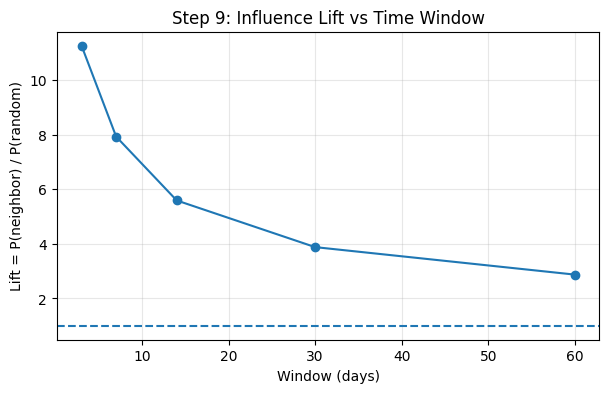

In [8]:
import numpy as np
import random
from datetime import timedelta
import matplotlib.pyplot as plt

def compute_lift(window_days, non_sample=5, seed=5200):

    rng = random.Random(seed + window_days)

    neighbor_success = 0
    neighbor_total = 0
    non_success = 0
    non_total = 0

    users = sorted(neighbors.keys())
    all_users = set(users)

    # Precompute non-neighbor pools
    non_pool = {u: list(all_users - neighbors[u] - {u}) for u in users}

    for u in users:

        user_rows = adopt[adopt["userId"] == u]

        for _, row in user_rows.iterrows():

            tag = row["tag"]
            t_u = row["timestamp"]
            window_end = t_u + timedelta(days=window_days)

            # ----- neighbors -----
            for v in neighbors[u]:

                t_v = adopt_lookup.get((v, tag), None)

                if t_v is not None:
                    neighbor_total += 1

                    if t_u < t_v <= window_end:
                        neighbor_success += 1

            # ----- random non-neighbors -----
            candidates = non_pool[u]

            if not candidates:
                continue

            sample_non = rng.sample(candidates, min(non_sample, len(candidates)))

            for v in sample_non:

                t_v = adopt_lookup.get((v, tag), None)

                if t_v is not None:
                    non_total += 1

                    if t_u < t_v <= window_end:
                        non_success += 1

    Pn = neighbor_success / neighbor_total if neighbor_total else 0
    Pr = non_success / non_total if non_total else 0
    lift = Pn / Pr if Pr > 0 else np.nan

    return Pn, Pr, lift


# Windows to test
windows = [3, 7, 14, 30, 60]

lifts = []

for w in windows:

    Pn, Pr, L = compute_lift(w)

    lifts.append(L)

    print(f"{w} days -> Lift = {L:.2f}")

# Plot
plt.figure(figsize=(7,4))

plt.plot(windows, lifts, marker="o")

plt.axhline(1.0, linestyle="--")

plt.title("Step 9: Influence Lift vs Time Window")
plt.xlabel("Window (days)")
plt.ylabel("Lift = P(neighbor) / P(random)")

plt.grid(True, alpha=0.3)

plt.show()

#### Step 9 — Influence Robustness Across Time Windows

To test whether the observed influence effect depends on the chosen time window, we compute the influence lift across multiple adoption windows: **3, 7, 14, 30, and 60 days**.

The influence lift is defined as:

Lift = P(adopt | neighbor adopted) / P(adopt | random adopted)

### Results

| Window (days) | Influence Lift |
|---|---|
| 3 | **11.26** |
| 7 | **7.93** |
| 14 | **5.59** |
| 30 | **3.88** |
| 60 | **2.87** |

### Interpretation

The lift is highest for **very short windows (3–7 days)**, indicating that tag adoption is strongly influenced by neighbors shortly after they adopt the tag. As the time window increases, the lift gradually decreases, suggesting that the immediate influence effect weakens over time.

However, the lift remains **above 1 across all time windows**, indicating that neighbor adoption consistently increases the probability of adoption compared to a random baseline.

### Conclusion

This robustness analysis confirms that the influence effect observed in Step 9 is **not sensitive to the choice of time window**. Instead, it reveals a natural diffusion pattern: influence is strongest shortly after exposure and gradually decays over time, while still remaining significantly above the random baseline.

## Neo4j Sample data

In [9]:
import pandas as pd

edges = pd.read_csv("user_similarity_topk_strict.csv")
edges["u1"] = edges["u1"].astype(int)
edges["u2"] = edges["u2"].astype(int)

# -----------------------------
# Users / Nodes
# -----------------------------
users = sorted(set(edges["u1"]).union(set(edges["u2"])))

nodes = pd.DataFrame({
    "userId": users
})

nodes.to_csv("neo4j_users.csv", index=False)

print("Users exported:", len(nodes))

# -----------------------------
# Similarity edges
# -----------------------------
edges_out = edges[["u1", "u2", "jaccard", "shared_tags"]].copy()
edges_out.to_csv("neo4j_similarity_edges.csv", index=False)

print("Edges exported:", len(edges_out))
print(edges_out.head())

Users exported: 1027
Edges exported: 2744
       u1      u2   jaccard  shared_tags
0   20028  131894  0.006427          127
1  131894  133047  0.007607          143
2    8405  111549  0.008935          241
3    8405  138325  0.008661          251
4    8405   91349  0.008350          235


In [10]:
import pandas as pd

adopt = pd.read_csv("user_tag_adoption_FINAL.csv")
adopt["userId"] = adopt["userId"].astype(int)

# keep only users in strict graph
graph_users = set(nodes["userId"])
adopt_small = adopt[adopt["userId"].isin(graph_users)].copy()

# optional: keep only top tags by frequency to reduce size
top_tags = adopt_small["tag"].value_counts().head(1000).index
adopt_small = adopt_small[adopt_small["tag"].isin(top_tags)].copy()

adopt_small.to_csv("neo4j_adoptions.csv", index=False)

print("Adoption rows exported:", len(adopt_small))
print("Unique tags exported:", adopt_small["tag"].nunique())

Adoption rows exported: 399111
Unique tags exported: 1000
